In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

RANDOM_STATE = 42

In [3]:
digits = load_digits()

pixel_data = digits.data
target = digits.target

pixel_data.shape

(1797, 64)

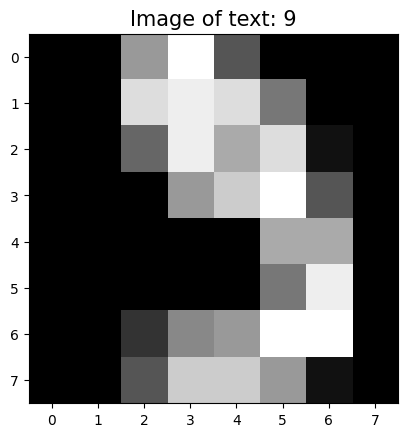

In [5]:
single_image = pixel_data[105, :].reshape(8, 8)

plt.imshow(single_image, cmap = 'gray')
plt.title(f"Image of text: {target[105]}", fontsize = 15)
plt.show()

Будем визуализировать данные на плоскости (n_components = 2)

In [6]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_transformed = tsne.fit_transform(pixel_data)

In [22]:
tsne_df = pd.DataFrame(np.column_stack((X_transformed, target)), columns = ['X', 'Y', 'Targets'])
#tsne_df.loc[:, 'Targets'] = target.astype(int)
tsne_df['Targets'] = tsne_df['Targets'].astype(int)

In [23]:
tsne_df.head()

,X,Y,Targets
0,-2.912159,-53.738060,0
1,10.212255,12.353485,1
2,-14.063310,19.054434,2
3,-36.460197,-6.440660,3
4,41.040726,7.676669,4


numpy.ndarray

Нарисуем результат

<Figure size 1000x800 with 0 Axes>

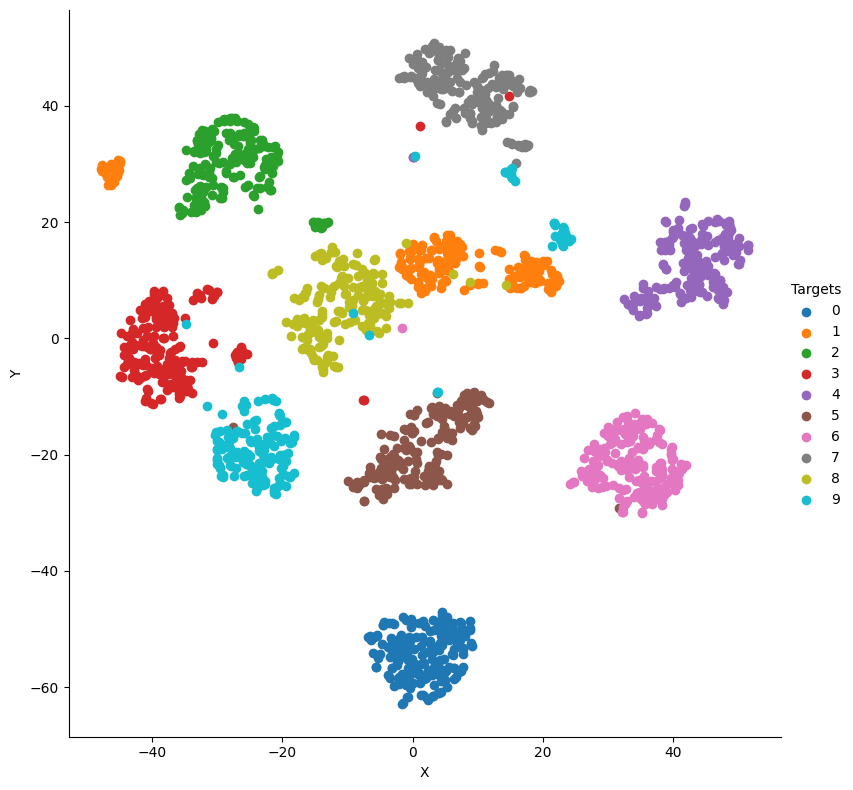

In [24]:
plt.figure(figsize = (10, 8))

g = sns.FacetGrid(data = tsne_df, hue = 'Targets', height = 8)

g.map(plt.scatter, 'X', 'Y').add_legend()

plt.show()